# 卷积层里的填充和步幅

## 填充

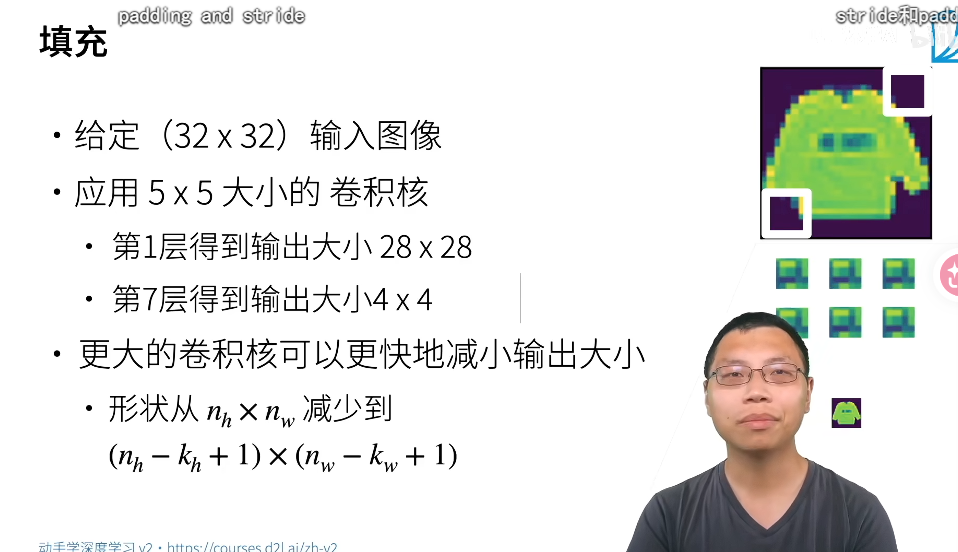

填充：输入3×3，输出2×2

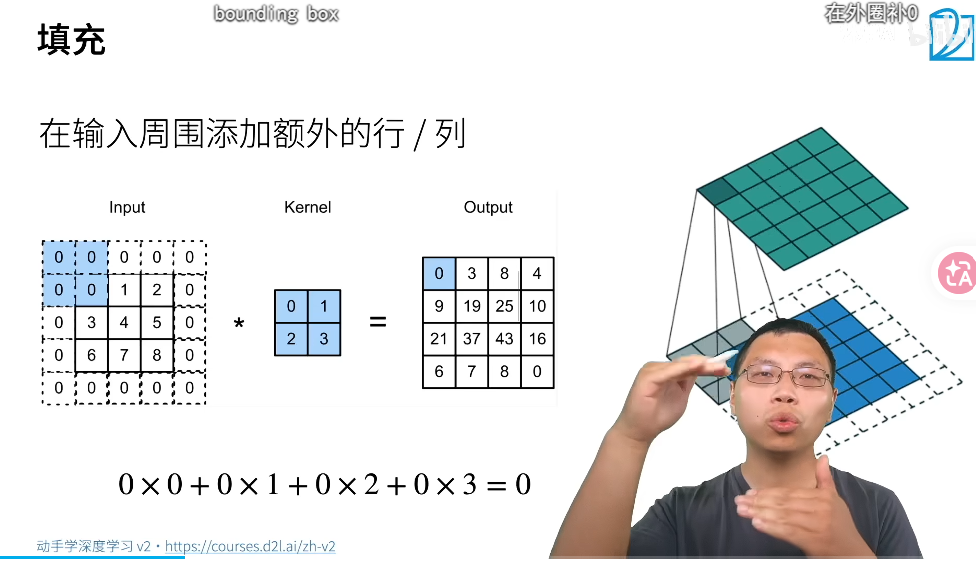

填充：输入3×3，输出4×4

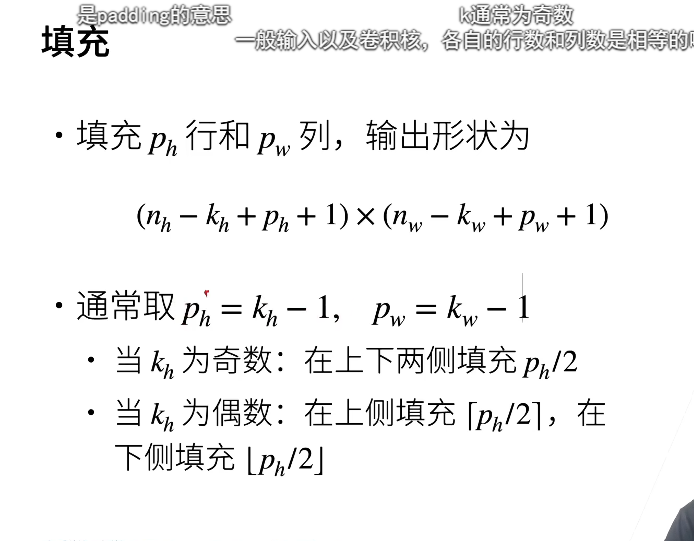

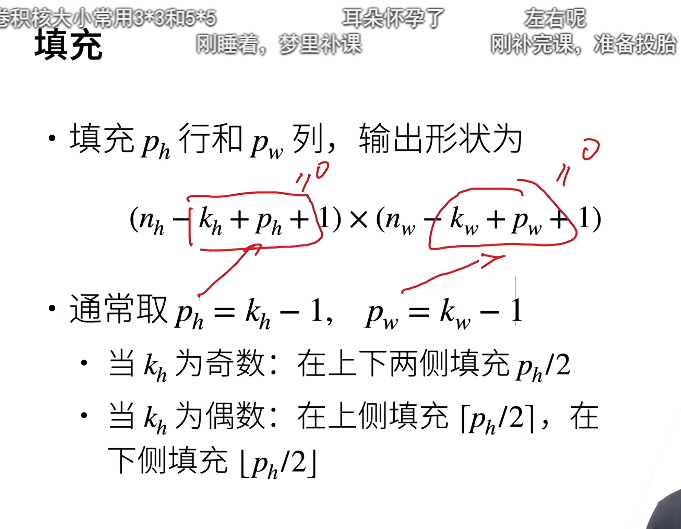

如果想让输入和输出形状一致：

1. 卷积核为奇数维k：在原矩阵上下两侧填充 (k-1)/2 行
2. 卷积核为偶数维k：在原矩阵上侧填充 (k-1)/2 + 1 行，在下侧填充 (k-1)/2 - 1 行

## 步幅

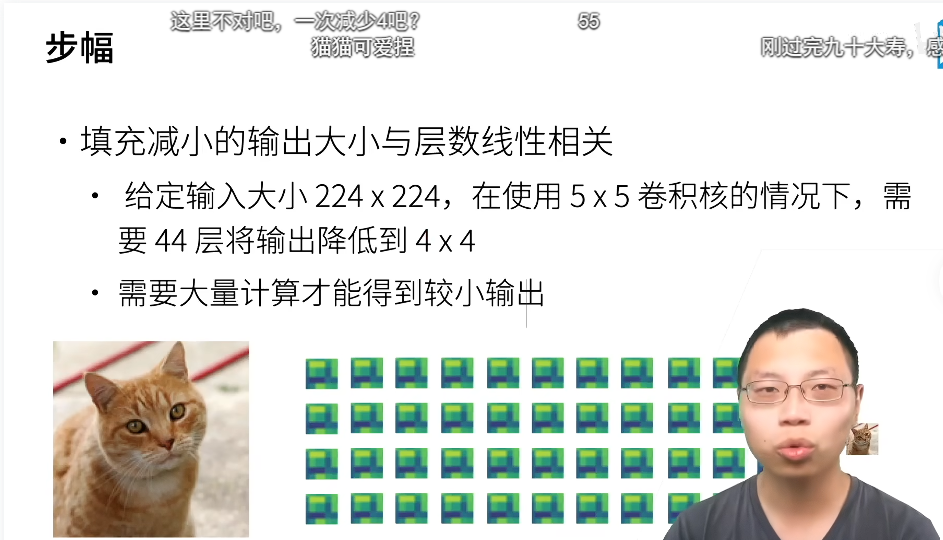

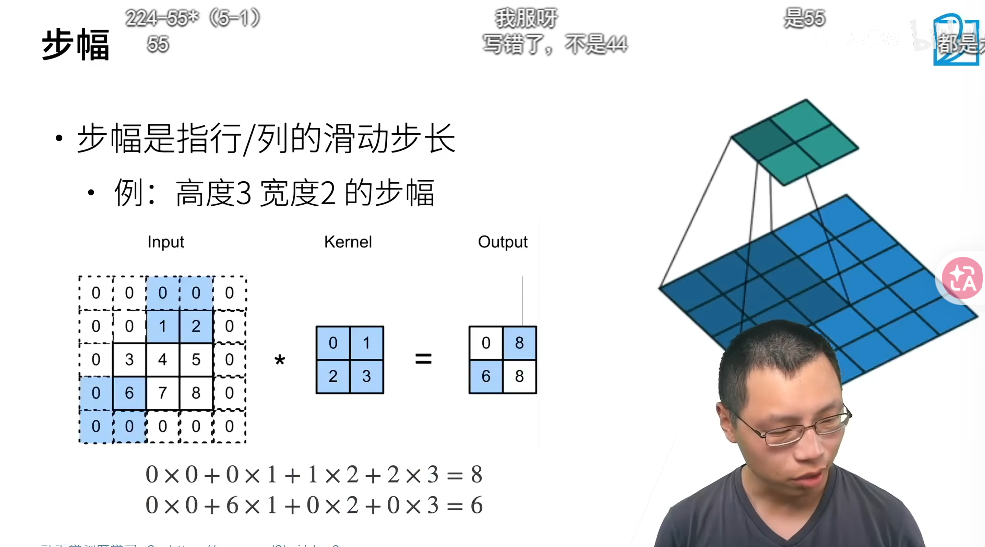

输入3×3，输出2×2

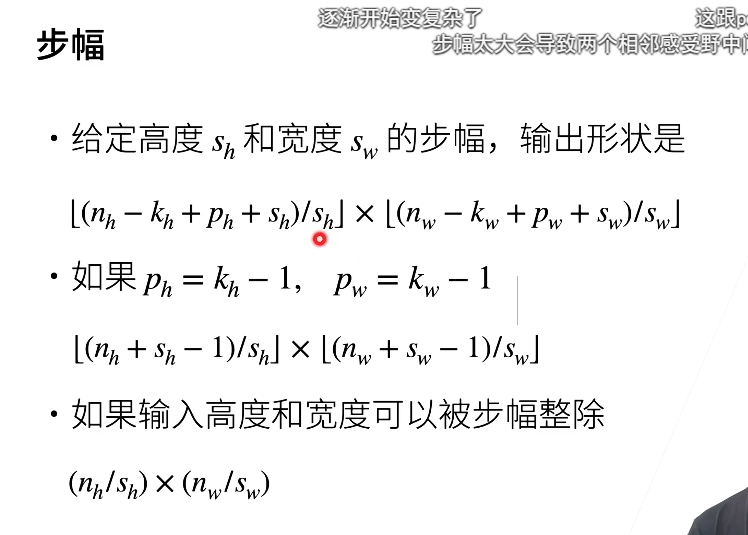

可以成倍减小输出大小

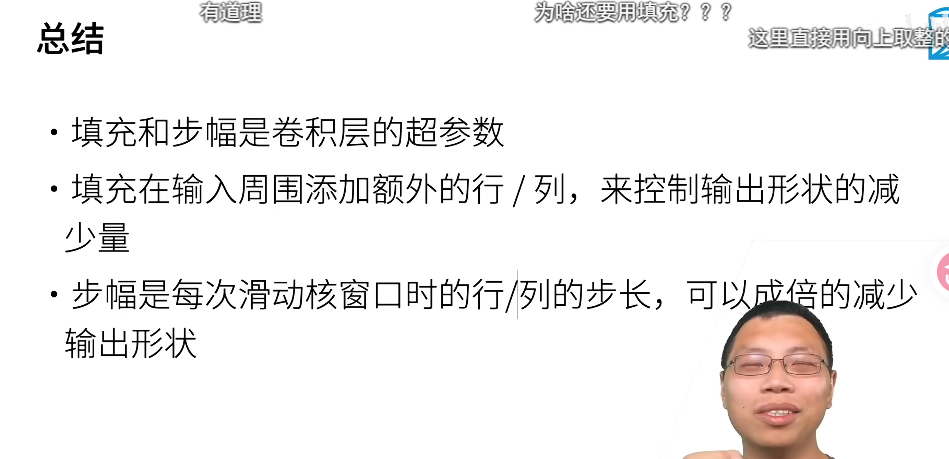

卷积核大小、填充、步幅都是卷积层超参数

填充一般取核维度-1；步幅一般取1，计算量较大时取2

重要程度：核大小 > 填充 > 步幅 

## 代码

创建⼀个⾼度和宽度为3的⼆维卷积层，并在所有侧边填充1个像素。给定⾼度
和宽度为8的输⼊，则输出的⾼度和宽度也是8。

In [1]:
import torch
from torch import nn
# 为了⽅便起⻅，我们定义了⼀个计算卷积层的函数。
# 此函数初始化卷积层权重，并对输⼊和输出提⾼和缩减相应的维数
def comp_conv2d(conv2d, X):
    # 这⾥的（1，1）表⽰批量⼤⼩和通道数都是1
    X = X.reshape((1, 1) + X.shape)
    Y = conv2d(X)
    # 省略前两个维度：批量⼤⼩和通道
    return Y.reshape(Y.shape[2:])
    
# 请注意，这⾥每边都填充了1⾏或1列，因此总共添加了2⾏或2列
conv2d = nn.Conv2d(1, 1, kernel_size=3, padding=1)
X = torch.rand(size=(8, 8))
comp_conv2d(conv2d, X).shape

torch.Size([8, 8])

填充不同行：上下填充2，左右填充1

In [2]:
conv2d = nn.Conv2d(1, 1, kernel_size=(5, 3), padding=(2, 1))
comp_conv2d(conv2d, X).shape

torch.Size([8, 8])

步幅调整为2，输出维度8/2=4

In [3]:
conv2d = nn.Conv2d(1, 1, kernel_size=3, padding=1, stride=2)
comp_conv2d(conv2d, X).shape

torch.Size([4, 4])

In [4]:
conv2d = nn.Conv2d(1, 1, kernel_size=(3, 5), padding=(0, 1), stride=(3, 4))
comp_conv2d(conv2d, X).shape

torch.Size([2, 2])